In [11]:
import pandas as pd

In [12]:
df = pd.read_csv(r"C:\Users\hp5cd\Desktop\bank-churn-analytics\data\feature_engineering\feature_engineered_data.csv")
transactions = pd.read_csv(r"C:\Users\hp5cd\Desktop\bank-churn-analytics\data\synthetic\transactions.csv")

In [13]:
df = pd.get_dummies(
    df,
    columns=['country', 'gender'],
    drop_first=True
)

In [14]:
from sklearn.model_selection import train_test_split

X = df.drop('churn', axis=1)
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    test_size=0.2,
    random_state=42
)

In [15]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [16]:
from sklearn.metrics import (

    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score

)

In [17]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [18]:
print(

    "Accuracy:",

    accuracy_score(y_test, y_pred)

)

print(

    "Precision:",

    precision_score(y_test, y_pred)

)

print(

    "Recall:",

    recall_score(y_test, y_pred)

)

print(

    "F1 Score:",

    f1_score(y_test, y_pred)

)

print(

    "ROC AUC:",

    roc_auc_score(y_test, y_prob)

)

Accuracy: 0.7825
Precision: 0.2878787878787879
Recall: 0.04668304668304668
F1 Score: 0.080338266384778
ROC AUC: 0.7389392474138237


In [19]:
from xgboost import XGBClassifier

In [20]:
xgb = XGBClassifier(
    eval_metric='logloss'
)

In [21]:
xgb.fit(
    X_train,
    y_train
)
xgb_pred = xgb.predict(X_test)

In [22]:
print(

    "F1 Score:",

    f1_score(y_test, xgb_pred)

)

F1 Score: 0.5648414985590778


In [23]:
importance = pd.DataFrame({

    'feature': X.columns,

    'importance': xgb.feature_importances_

})

In [24]:
importance = importance.sort_values(

    by='importance',

    ascending=False

)

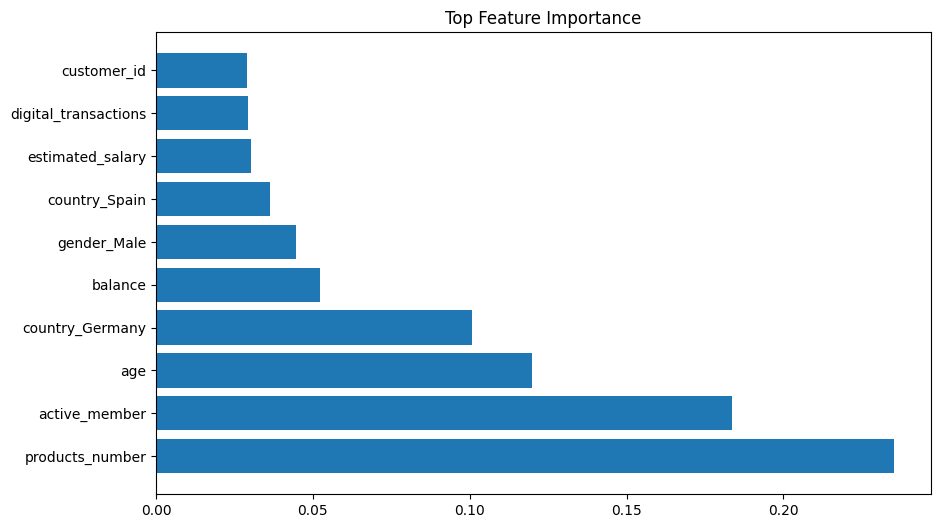

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(

    importance['feature'][:10],

    importance['importance'][:10]

)

plt.title(
    "Top Feature Importance"
)

plt.savefig(
    r"C:\Users\hp5cd\Desktop\bank-churn-analytics\visuals\feature_importance.png"
)

plt.show()

In [26]:
pip install shap

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
import shap

C:\Users\hp5cd\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [28]:
explainer = shap.Explainer(xgb)
shap_values = explainer(X_test)

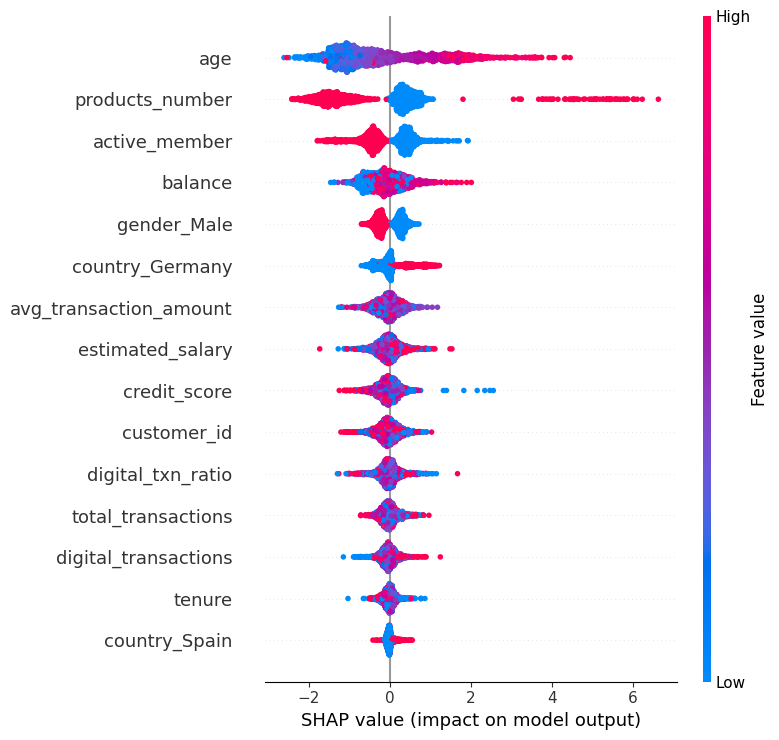

In [29]:
shap.summary_plot(

    shap_values,

    X_test,

    show=False

)

plt.savefig(
    r"C:\Users\hp5cd\Desktop\bank-churn-analytics\visuals\shap_summary.png"
)

plt.show()

In [30]:
df['estimated_profit'] = (

    df['balance']

    * 0.03

)

In [31]:
df['predicted_churn'] = xgb.predict(X)

In [32]:
high_risk = df[

    df['predicted_churn'] == 1

]

In [33]:
revenue_risk = high_risk[
    'estimated_profit'
].sum()

In [34]:
print(

    "Estimated Revenue At Risk:",

    revenue_risk

)

Estimated Revenue At Risk: 4975349.2272


In [35]:
df.to_csv( r"C:\Users\hp5cd\Desktop\bank-churn-analytics\data\final_churn_dataset.csv", index=False )

In [36]:
transactions['date'] = pd.to_datetime(
    transactions['date']
)

In [37]:
transactions['month'] = (

    transactions['date']

    .dt.to_period('M')

    .astype(str)

)

In [38]:
monthly_txn = (

    transactions

    .groupby('month')

    .size()

    .reset_index(name='transaction_count')

)

In [39]:
monthly_txn.to_csv(

    r"C:\Users\hp5cd\Desktop\bank-churn-analytics\data\monthly_transactions.csv",

    index=False

)


In [40]:
df = pd.get_dummies(df)

In [ ]:
df.to_csv(
    "final_churn_dataset.csv",
    index=False
)

In [46]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(
    y_test,
    xgb_pred
)

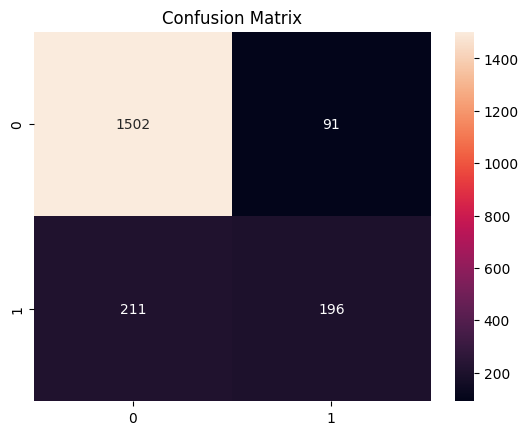

In [49]:
import seaborn as sns

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "Confusion Matrix"
)

plt.savefig(
    r"C:\Users\hp5cd\Desktop\bank-churn-analytics\visuals\confusion_matrix.png"
)

plt.show()

In [50]:
importance.to_csv(
    "feature_importance.csv",
    index=False
)